# IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, roc_auc_score,f1_score, confusion_matrix,RocCurveDisplay)
from imblearn.over_sampling import SMOTE
import shap
import joblib
print("All libraries imported successfully")

All libraries imported successfully


# LOAD DATASET

In [8]:
df = pd.read_csv('dataset.csv')  # important: this CSV uses semicolon separator
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{list(df.columns)}")
print(f"\nTarget column unique values:")
print(df['Target'].value_counts())
df.head(3)

Shape: (4424, 35)

Columns:
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target']

Target column unique values:
Target
G

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout


# EDA

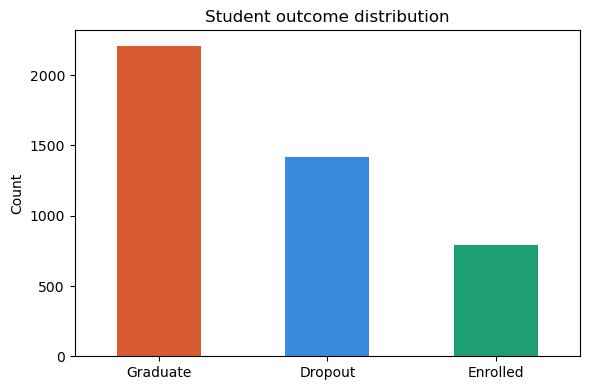

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Dropout rate: 32.1%


In [9]:
plt.figure(figsize=(6, 4))
colors = ['#D85A30', '#378ADD', '#1D9E75']
df['Target'].value_counts().plot(kind='bar', color=colors, edgecolor='none')
plt.title('Student outcome distribution')
plt.xlabel('')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(df['Target'].value_counts())
print(f"\nDropout rate: {(df['Target'] == 'Dropout').mean()*100:.1f}%")

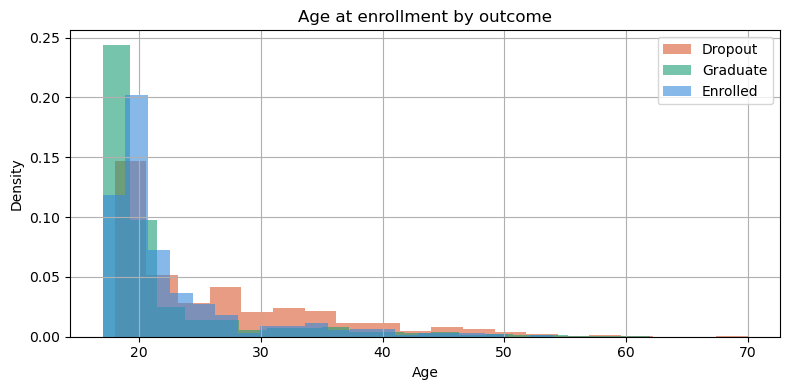

In [11]:
plt.figure(figsize=(8, 4))
for outcome, color in zip(['Dropout', 'Graduate', 'Enrolled'],['#D85A30', '#1D9E75', '#378ADD']):
    subset = df[df['Target'] == outcome]['Age at enrollment']
    subset.hist(bins=20, alpha=0.6, color=color, label=outcome, density=True)
plt.title('Age at enrollment by outcome')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

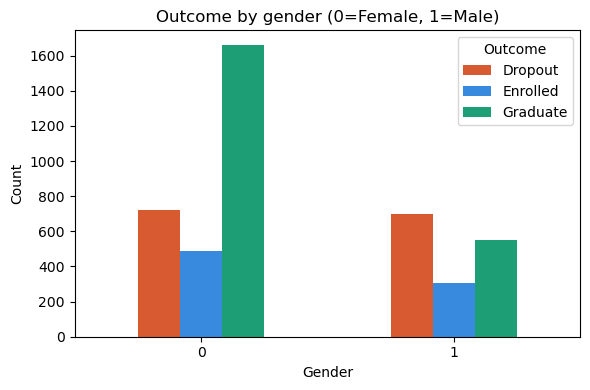

In [12]:
gender_outcome = df.groupby(['Gender', 'Target']).size().unstack(fill_value=0)
gender_outcome.plot(kind='bar', figsize=(6, 4),color=['#D85A30', '#378ADD', '#1D9E75'], edgecolor='none')
plt.title('Outcome by gender (0=Female, 1=Male)')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Outcome')
plt.tight_layout()
plt.show()

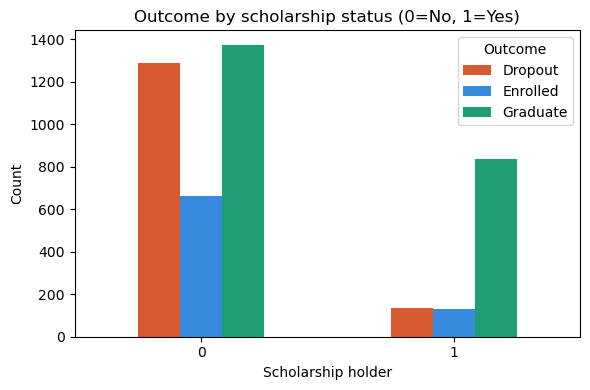

In [13]:
scholarship = df.groupby(['Scholarship holder', 'Target']).size().unstack(fill_value=0)
scholarship.plot(kind='bar', figsize=(6, 4),color=['#D85A30', '#378ADD', '#1D9E75'], edgecolor='none')
plt.title('Outcome by scholarship status (0=No, 1=Yes)')
plt.xlabel('Scholarship holder')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Outcome')
plt.tight_layout()
plt.show()

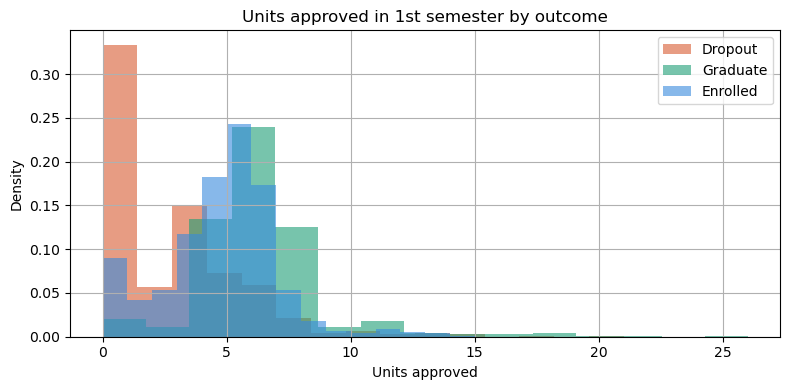

In [14]:
plt.figure(figsize=(8, 4))
for outcome, color in zip(['Dropout', 'Graduate', 'Enrolled'],['#D85A30', '#1D9E75', '#378ADD']):
    subset = df[df['Target'] == outcome]['Curricular units 1st sem (approved)']
    subset.hist(bins=15, alpha=0.6, color=color, label=outcome, density=True)
plt.title('Units approved in 1st semester by outcome')
plt.xlabel('Units approved')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

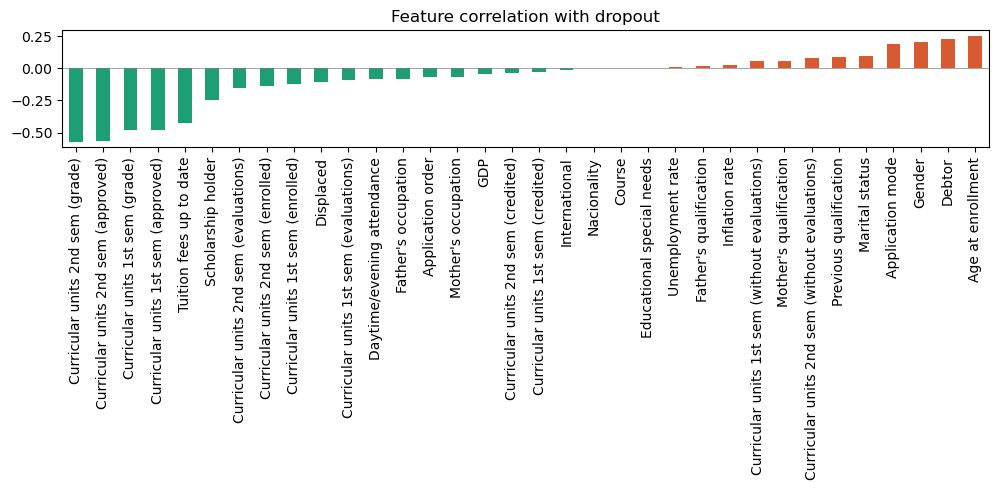

Top 5 features positively correlated with dropout:
Marital status       0.093712
Application mode     0.188908
Gender               0.203983
Debtor               0.229407
Age at enrollment    0.254215
Name: Target_binary, dtype: float64

Top 5 features negatively correlated with dropout:
Curricular units 2nd sem (grade)      -0.571792
Curricular units 2nd sem (approved)   -0.569500
Curricular units 1st sem (grade)      -0.480669
Curricular units 1st sem (approved)   -0.479112
Tuition fees up to date               -0.429149
Name: Target_binary, dtype: float64


In [15]:
df_encoded = df.copy()
df_encoded['Target_binary'] = (df_encoded['Target'] == 'Dropout').astype(int)
df_encoded.drop(columns=['Target'], inplace=True)
correlations = df_encoded.corr()['Target_binary'].drop('Target_binary').sort_values()
plt.figure(figsize=(10, 5))
correlations.plot(kind='bar',
    color=['#D85A30' if x > 0 else '#1D9E75' for x in correlations],
    edgecolor='none')
plt.title('Feature correlation with dropout')
plt.axhline(0, color='gray', linewidth=0.5)
plt.tight_layout()
plt.show()
print("Top 5 features positively correlated with dropout:")
print(correlations.tail(5))
print("\nTop 5 features negatively correlated with dropout:")
print(correlations.head(5))

# PREPROCESSING

In [16]:
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Shape: {df.shape}")

Missing values: 0
Shape: (4424, 35)


In [17]:
df['target'] = (df['Target'] == 'Dropout').astype(int)
df.drop(columns=['Target'], inplace=True)
print("Target distribution after binarisation:")
print(df['target'].value_counts())
print(f"Dropout rate: {df['target'].mean()*100:.1f}%")

Target distribution after binarisation:
target
0    3003
1    1421
Name: count, dtype: int64
Dropout rate: 32.1%


In [18]:
X = df.drop(columns=['target'])
y = df['target']
print(f"Features: {X.shape[1]}")
print(f"All features numeric: {X.dtypes.eq('object').sum() == 0}")

Features: 34
All features numeric: True


In [19]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print("Features scaled.")
print(X_scaled.describe().round(2).loc[['mean', 'std']].head())

Features scaled.
      Marital status  Application mode  Application order  Course  \
mean            -0.0              -0.0               -0.0    -0.0   
std              1.0               1.0                1.0     1.0   

      Daytime/evening attendance  Previous qualification  Nacionality  \
mean                         0.0                    -0.0          0.0   
std                          1.0                     1.0          1.0   

      Mother's qualification  Father's qualification  Mother's occupation  \
mean                    -0.0                     0.0                 -0.0   
std                      1.0                     1.0                  1.0   

      ...  Curricular units 1st sem (without evaluations)  \
mean  ...                                             0.0   
std   ...                                             1.0   

      Curricular units 2nd sem (credited)  \
mean                                 -0.0   
std                                   1.0   

   

**BEFORE SMOTE**

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,test_size=0.2,random_state=42,stratify=y)
print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")
print(f"\nDropout cases in test set: {y_test.sum()}")

Train size: (3539, 34)
Test size:  (885, 34)

Dropout cases in test set: 284


**AFTER SMOTE**

In [22]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("After SMOTE — training set:")
print(f"  Class 0 (non-dropout): {(y_train_sm == 0).sum()}")
print(f"  Class 1 (dropout):     {(y_train_sm == 1).sum()}")
print(f"  Total rows: {len(X_train_sm)}")

After SMOTE — training set:
  Class 0 (non-dropout): 2402
  Class 1 (dropout):     2402
  Total rows: 4804


# TRAINING MODELS

In [23]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}
results = {}
trained_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    results[name] = {'ROC-AUC': auc, 'F1': f1}
    trained_models[name] = model
    print(f"  ROC-AUC: {auc:.4f}  |  F1: {f1:.4f}\n")
print("Best by F1:", max(results, key=lambda k: results[k]['F1']))

Training Logistic Regression...
  ROC-AUC: 0.9281  |  F1: 0.8061

Training Random Forest...
  ROC-AUC: 0.9302  |  F1: 0.8124

Training XGBoost...
  ROC-AUC: 0.9279  |  F1: 0.8167

Best by F1: XGBoost


**EVALUATE**

In [24]:
best_name = max(results, key=lambda k: results[k]['F1'])
best_model = trained_models[best_name]
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]
print(f"=== {best_name} ===")
print(classification_report(y_test, y_pred,
      target_names=['Non-dropout', 'Dropout']))

=== XGBoost ===
              precision    recall  f1-score   support

 Non-dropout       0.90      0.93      0.92       601
     Dropout       0.84      0.79      0.82       284

    accuracy                           0.89       885
   macro avg       0.87      0.86      0.87       885
weighted avg       0.88      0.89      0.88       885



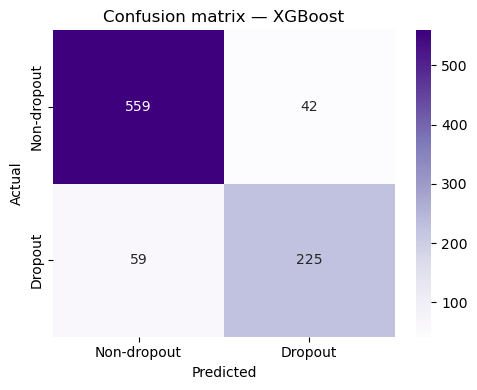

In [25]:
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred),annot=True, fmt='d', cmap='Purples',xticklabels=['Non-dropout', 'Dropout'],yticklabels=['Non-dropout', 'Dropout'])
plt.title(f'Confusion matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

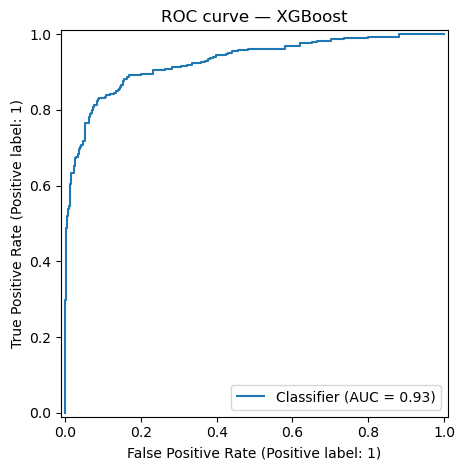

In [26]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title(f'ROC curve — {best_name}')
plt.tight_layout()
plt.show()

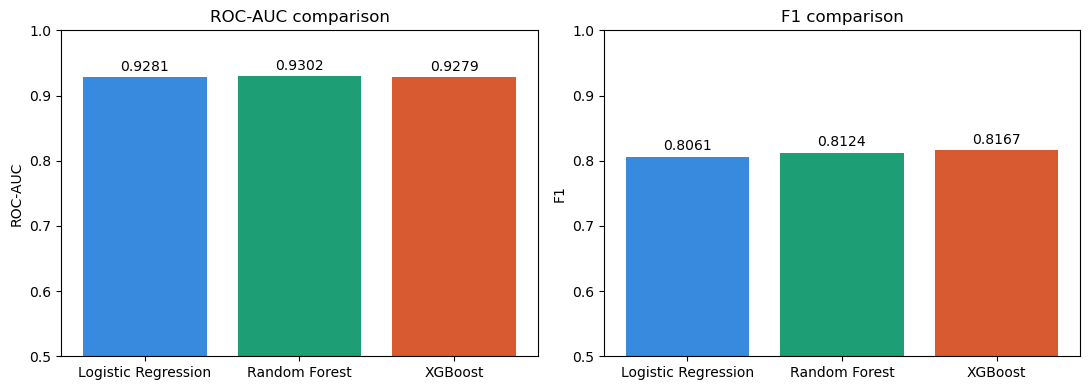

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
names = list(results.keys())
colors = ['#378ADD', '#1D9E75', '#D85A30']

for ax, metric in zip(axes, ['ROC-AUC', 'F1']):
    vals = [results[n][metric] for n in names]
    bars = ax.bar(names, vals, color=colors, edgecolor='none')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    ax.set_ylim(0.5, 1.0)
    ax.set_title(f'{metric} comparison')
    ax.set_ylabel(metric)

plt.tight_layout()
plt.show()

# SHAP AND SAVING MODEL

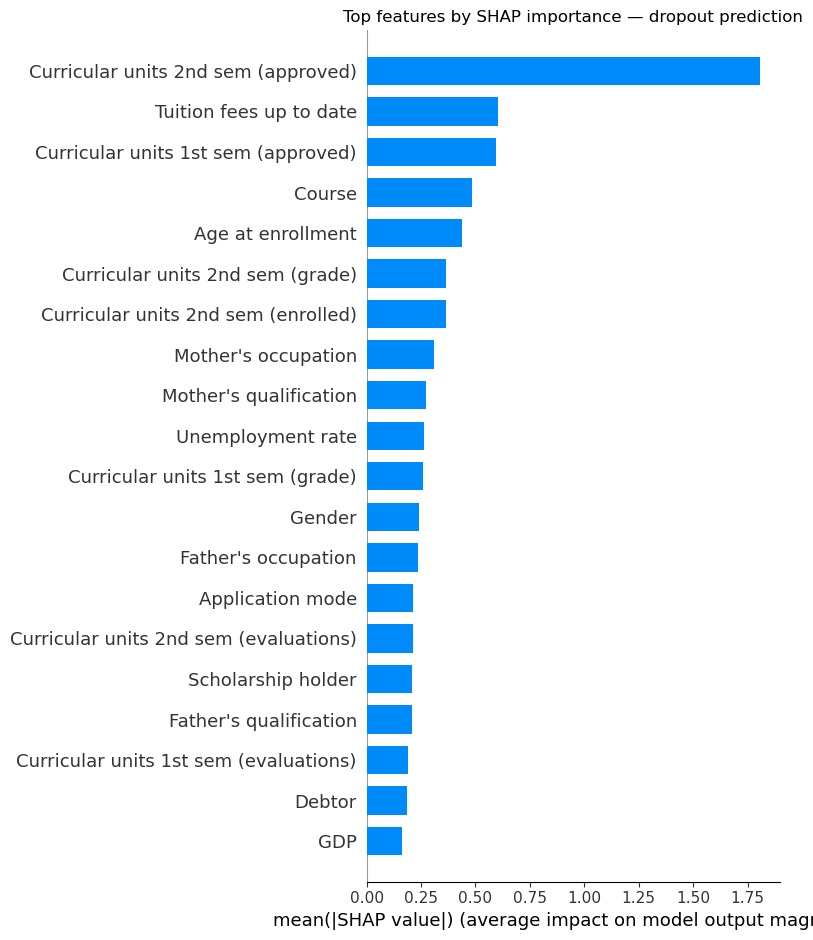

In [28]:
xgb_model = trained_models['XGBoost']
explainer = shap.TreeExplainer(xgb_model)
X_sample = X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(X_sample)
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.title('Top features by SHAP importance — dropout prediction')
plt.tight_layout()
plt.savefig('shap_dropout_summary.png', dpi=150, bbox_inches='tight')
plt.show()

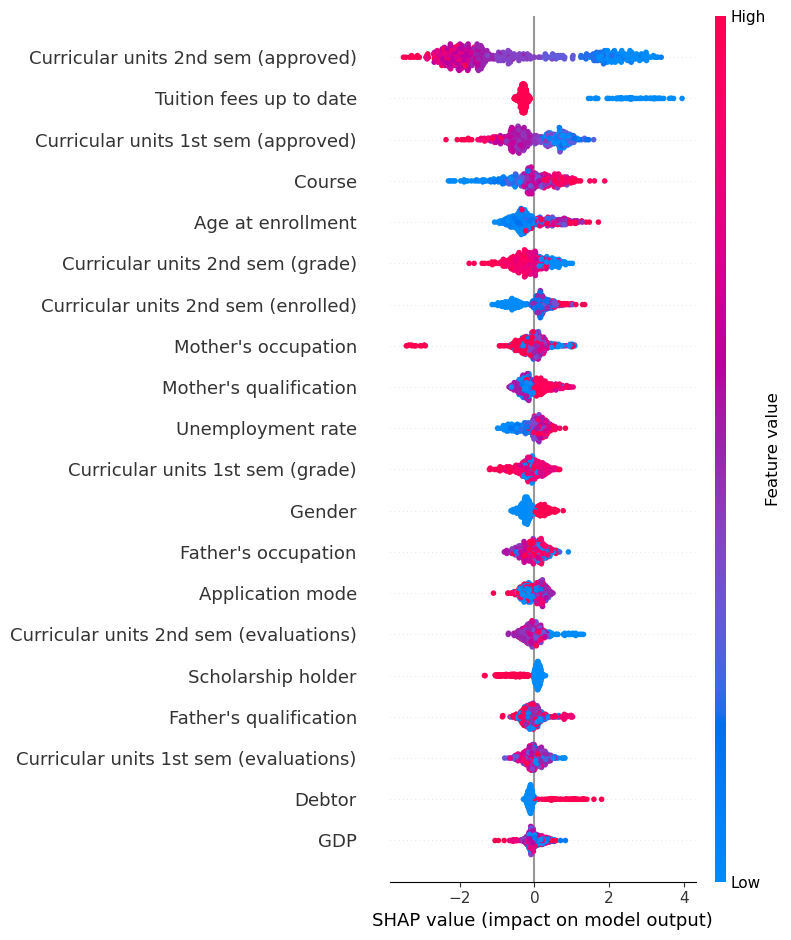

In [29]:
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.show()

In [30]:
joblib.dump(xgb_model, 'dropout_prediction_model.pkl')
joblib.dump(scaler, 'dropout_scaler.pkl')
print("Model saved: dropout_prediction_model.pkl")
print("Scaler saved: dropout_scaler.pkl")
print(f"\nNotebook 3 complete!")
print(f"Best model: {best_name}")
for metric, val in results[best_name].items():
    print(f"{metric}: {val:.4f}")

Model saved: dropout_prediction_model.pkl
Scaler saved: dropout_scaler.pkl

Notebook 3 complete!
Best model: XGBoost
ROC-AUC: 0.9279
F1: 0.8167
